In [ ]:
!pip install git+https://github.com/KrishnaswamyLab/omics_toolbox.git --no-deps

# MIOFlow — Cancer Plasticity Data (Multi-Branch)

## Workflow
1. Load pre-processed Cancer Plasticity AnnData
2. Train a **GAGA autoencoder** — learns a geometry-preserving latent embedding from PCA, regularised by PHATE distances
3. Cluster cells in GAGA latent space and assign clusters to branches
4. Pass each branch subset to `MIOFlow` and call `fit()` — trains a Neural ODE per branch
5. Inspect losses and trajectories
6. `decode_to_gene_space()` — maps trajectories back through the GAGA decoder and PCA components to recover gene-level predictions

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from mioflow import MIOFlow, fit_gaga

## 1. Load Data

In [2]:
adata = sc.read_h5ad('../../data/processed/cancer_plasticity/preprocessed_cancer_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 15970 × 19366
    obs: 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'condition_colors', 'pca'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'

Set the time column for your dataset. The Cancer Plasticity data uses `time_bin` (0–4 corresponding to Day 0 through Day 30).

In [3]:
time_column = 'time_bin'  # Set the time_column for your dataset

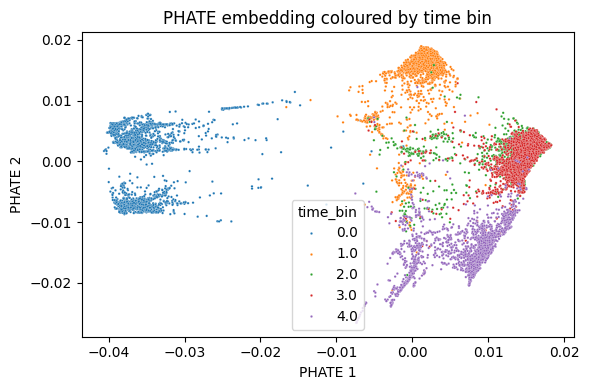

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    x=adata.obsm['X_phate'][:, 0],
    y=adata.obsm['X_phate'][:, 1],
    hue=adata.obs[time_column],
    palette='tab10',
    s=3,
    ax=ax,
)
ax.set_xlabel('PHATE 1')
ax.set_ylabel('PHATE 2')
ax.set_title('PHATE embedding coloured by time bin')
plt.tight_layout()
plt.show()

## 2. Train GAGA Autoencoder

GAGA trains a two-phase autoencoder on PCA embeddings, regularised by PHATE distances:

- **Phase 1** — encoder learns a geometry-preserving latent space (distance preservation loss, decoder frozen)
- **Phase 2** — decoder learns to reconstruct PCA coordinates (reconstruction loss, encoder frozen)

The resulting latent space is where the MIOFlow ODE will be trained.

In [6]:
gaga_model = fit_gaga(
    X_pca      = adata.obsm['X_pca'],
    X_phate    = adata.obsm['X_phate'],
    latent_dim = 2,
    hidden_dims= [128, 64],
    batch_size = 512,
    encoder_epochs=500,
    decoder_epochs=500,
    learning_rate=1e-3,
    dist_weight_phase1=1.0,
    recon_weight_phase2=1.0,
)

GAGA architecture: 50 → 2
Phase 1: Training encoder (decoder frozen) for distance preservation
Training GAGA on device: cpu
Encoder frozen: False, Decoder frozen: True
Reconstruction weight: 0.0, Distance weight: 1.0


Epochs: 100%|██████████| 500/500 [01:51<00:00,  4.49it/s, train_loss=0.0022, recon=1.0292, dist=0.0022]



Phase 2: Training decoder (encoder frozen) for reconstruction
Training GAGA on device: cpu
Encoder frozen: True, Decoder frozen: False
Reconstruction weight: 1.0, Distance weight: 0.0


Epochs: 100%|██████████| 500/500 [01:45<00:00,  4.73it/s, train_loss=0.7840, recon=0.7840, dist=0.0021]


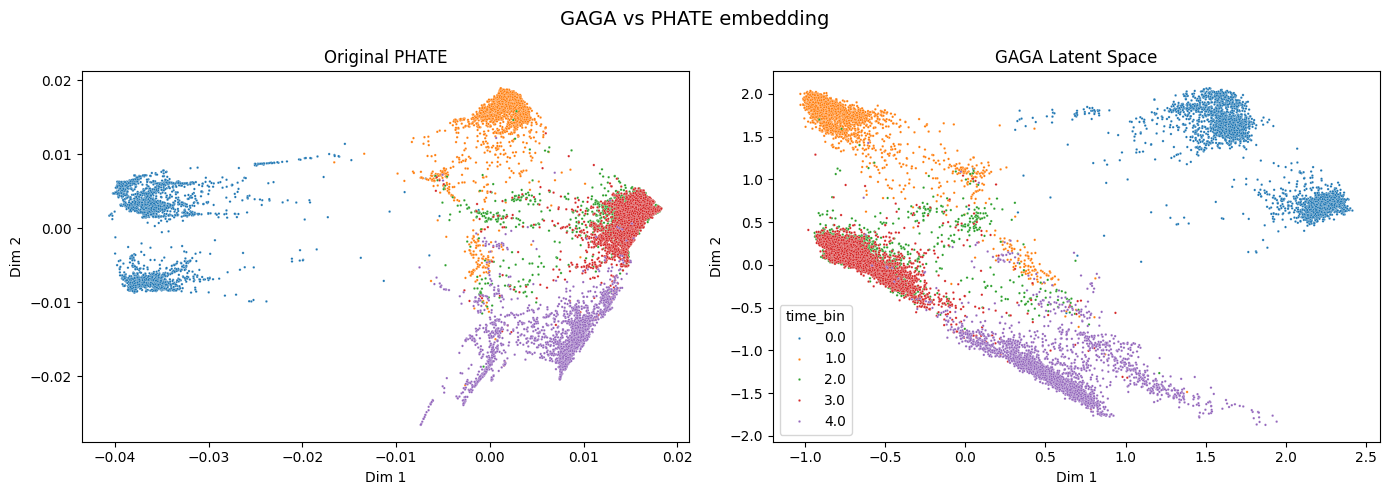

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in zip(
    axes,
    ['X_phate', 'X_gaga'],
    ['Original PHATE', 'GAGA Latent Space'],
):
    sns.scatterplot(
        x=adata.obsm[key][:, 0],
        y=adata.obsm[key][:, 1],
        hue=adata.obs[time_column],
        palette='tab10',
        s=3,
        ax=ax,
        legend=(ax == axes[-1]),  # legend on right panel only
    )
    ax.set_title(title)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

plt.suptitle('GAGA vs PHATE embedding', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Branch Identification

Cluster cells in GAGA latent space with K-means, then manually assign each cluster to a branch.

K-means clusters found: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7')]


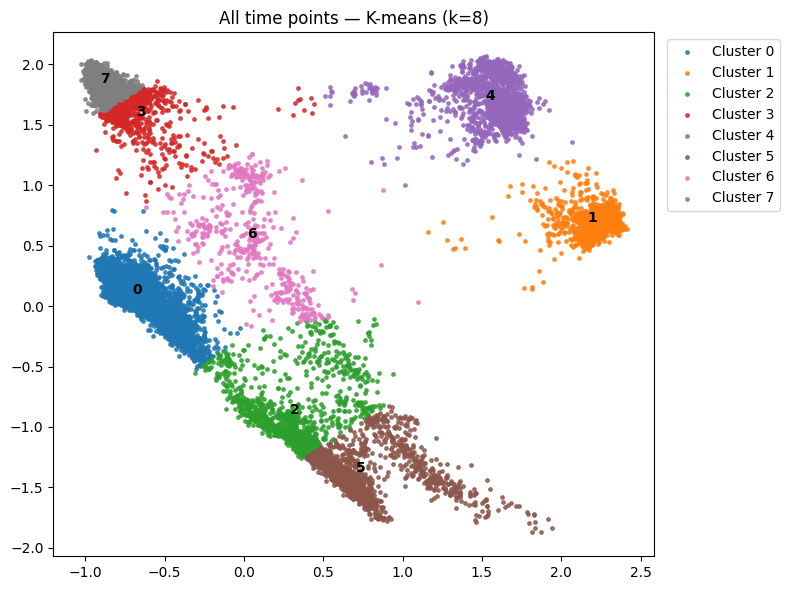

In [15]:
from sklearn.cluster import KMeans

# ── K-means clustering on ALL time points ────────────────────────────────────
X_all = adata.obsm['X_gaga']

n_clusters = 8   # ← tune this
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_all).astype(str)
print('K-means clusters found:', sorted(set(cluster_labels), key=int))

# ── Store in adata for downstream use ─────────────────────────────────────────
adata.obs['kmeans_cluster'] = cluster_labels

# ── Visualise clusters ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
palette = plt.cm.tab10.colors
for cl in sorted(set(cluster_labels), key=int):
    mask_cl = cluster_labels == cl
    ax.scatter(
        X_all[mask_cl, 0], X_all[mask_cl, 1],
        s=6, alpha=0.8, color=palette[int(cl) % 10], label=f'Cluster {cl}',
    )
    centroid = X_all[mask_cl].mean(axis=0)
    ax.annotate(f'{cl}', centroid, fontsize=10, fontweight='bold', ha='center')

ax.set_title(f'All time points — K-means (k={n_clusters})')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

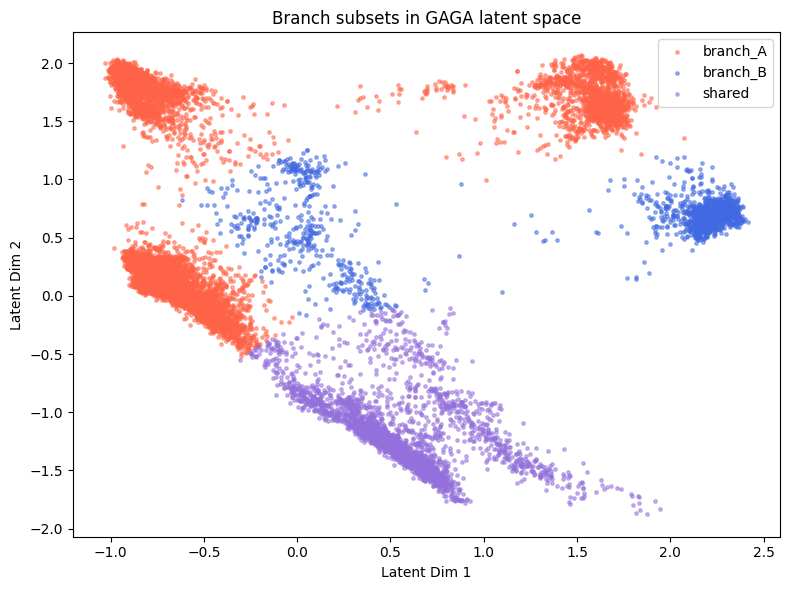

In [23]:
from itertools import combinations

# ── Config ────────────────────────────────────────────────────────────────────
branch_names = ['branch_A', 'branch_B']
branch_colors = {'branch_A': 'tomato', 'branch_B': 'royalblue'}
shared_color = 'mediumpurple'

# ── After inspecting the plot above, map each cluster → branch(es) ───────────
cluster_to_branches = {
    '0': ['branch_A'],
    '1': ['branch_B'],
    '2': ['branch_A', 'branch_B'],
    '3': ['branch_A'],
    '4': ['branch_A'],
    '5': ['branch_A', 'branch_B'],
    '6': ['branch_B'],
    '7': ['branch_A'],
}

# ── Build per-branch masks ────────────────────────────────────────────────────
branch_masks = {}
for branch_name in branch_names:
    branch_masks[branch_name] = np.array([
        cluster_labels[i] in cluster_to_branches
        and branch_name in cluster_to_branches[cluster_labels[i]]
        for i in range(adata.n_obs)
    ])

# Shared = belongs to 2+ branches
shared_mask = np.zeros(adata.n_obs, dtype=bool)
for b1, b2 in combinations(branch_names, 2):
    shared_mask |= (branch_masks[b1] & branch_masks[b2])

# ── Build per-branch adata subsets ────────────────────────────────────────────
adata_branches = {}
for branch_name in branch_names:
    exclusive = branch_masks[branch_name] & ~shared_mask
    adata_branches[branch_name] = adata[exclusive].copy()
    counts = adata_branches[branch_name].obs[time_column].value_counts().sort_index()

adata_branches['shared'] = adata[shared_mask].copy()
counts = adata_branches['shared'].obs[time_column].value_counts().sort_index()


# ── Visualise branch subsets ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for branch_name in branch_names:
    X = adata_branches[branch_name].obsm['X_gaga']
    ax.scatter(X[:, 0], X[:, 1], s=6, alpha=0.5,
               color=branch_colors[branch_name], label=branch_name)

X_shared = adata_branches['shared'].obsm['X_gaga']
ax.scatter(X_shared[:, 0], X_shared[:, 1], s=6, alpha=0.5,
           color=shared_color, label='shared')

ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_title('Branch subsets in GAGA latent space')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Configure and Initialise MIOFlow

Pass the trained `gaga_model` to `MIOFlow` for each branch subset.
`MIOFlow` will use the encoder to embed cells into latent space for ODE training, and the decoder in `decode_to_gene_space()`.

In [ ]:
import importlib
import mioflow
importlib.reload(mioflow)

mioflow_models = {}
for branch in ['branch_A', 'branch_B']:
    mioflow_models[branch] = mioflow.MIOFlow(
        adata_branches[branch],
        gaga_model=gaga_model,
        obs_time_key=time_column,
        debug_level='info',
        hidden_dim=132,
        use_cuda=torch.cuda.is_available(),
        momentum_beta=0.0,
        scheduler_type='cosine',
        learning_rate=1e-3,
        scheduler_t_max=100,
        scheduler_min_lr=1e-5,
        n_epochs=100,
        use_density_loss=True,
        lambda_ot=1.0,
        lambda_density=0.0,
        lambda_energy=0.1,
        energy_time_steps=20,
        sample_size=None,
        n_trajectories=50,
        n_bins=100,
        exp_dir='.',
    )

2026-03-10 14:36:06,520 - MIOFlow - INFO - MIOFlow initialised | 11365 cells, 19366 genes | device=cpu
2026-03-10 14:36:06,523 - MIOFlow - INFO - MIOFlow initialised | 1695 cells, 19366 genes | device=cpu


## 5. Fit — `~5 minutes`

`fit()` trains the Neural ODE in GAGA latent space using optimal transport for each branch.

In [25]:
for branch, model in mioflow_models.items():
    print(f'\n── Fitting branch: {branch} ──')
    model.fit()
    print(model)

2026-03-10 14:36:08,002 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=32
2026-03-10 14:36:08,003 - MIOFlow - INFO - Global training: 100 epochs



── Fitting branch: branch_A ──


Training (global):   0%|          | 0/100 [00:00<?, ?it/s]/Users/joaofelipe/Yale/github_projects/omics_toolbox/.venv/lib/python3.10/site-packages/ot/lp/_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)
Training (global): 100%|██████████| 100/100 [05:21<00:00,  3.21s/it]
2026-03-10 14:41:29,247 - MIOFlow - INFO - Trajectories generated: shape=(100, 50, 2)
2026-03-10 14:41:29,248 - MIOFlow - INFO - MIOFlow fitting completed.
2026-03-10 14:41:29,249 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=32
2026-03-10 14:41:29,249 - MIOFlow - INFO - Global training: 100 epochs


MIOFlow(n_obs=11365, gaga=Autoencoder, n_epochs=100, trajectories=(100, 50, 2), status=fitted)

── Fitting branch: branch_B ──


Training (global): 100%|██████████| 100/100 [00:24<00:00,  4.14it/s]
2026-03-10 14:41:53,452 - MIOFlow - INFO - Trajectories generated: shape=(100, 50, 2)
2026-03-10 14:41:53,452 - MIOFlow - INFO - MIOFlow fitting completed.


MIOFlow(n_obs=1695, gaga=Autoencoder, n_epochs=100, trajectories=(100, 50, 2), status=fitted)


## 6. Training Losses

After fitting:
- `model.losses` — dict with keys `epoch`, `total_loss`, `ot_loss`, `density_loss`, `energy_loss`

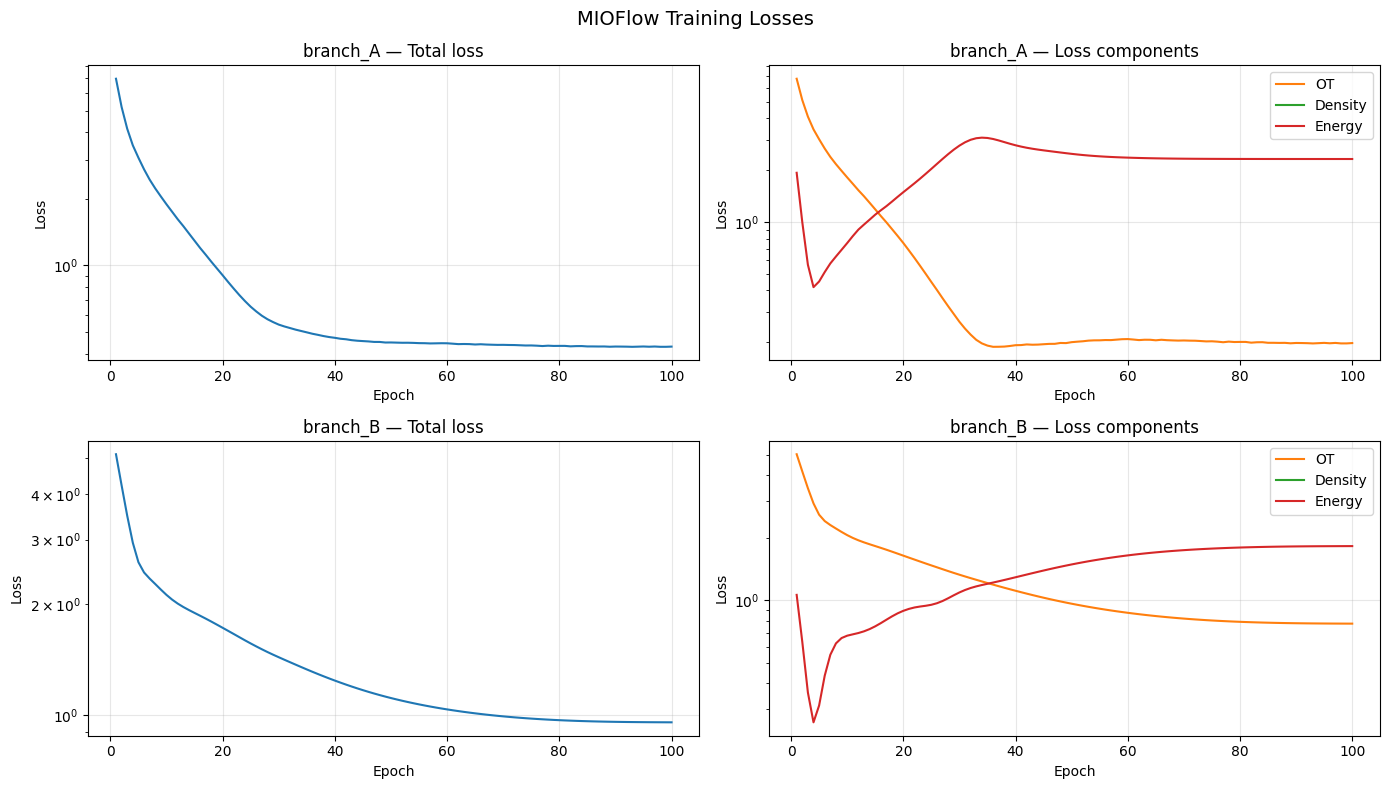

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (branch, model) in enumerate(mioflow_models.items()):
    epochs = model.losses['epoch']

    axes[row, 0].plot(epochs, model.losses['total_loss'], color='tab:blue')
    axes[row, 0].set_title(f'{branch} — Total loss')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].set_yscale('log')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(epochs, model.losses['ot_loss'],      label='OT',      color='tab:orange')
    axes[row, 1].plot(epochs, model.losses['density_loss'], label='Density', color='tab:green')
    axes[row, 1].plot(epochs, model.losses['energy_loss'],  label='Energy',  color='tab:red')
    axes[row, 1].set_title(f'{branch} — Loss components')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Loss')
    axes[row, 1].set_yscale('log')
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle('MIOFlow Training Losses', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Trajectories in GAGA Latent Space

`model.trajectories` has shape **`(n_bins, n_trajectories, latent_dim)`**.

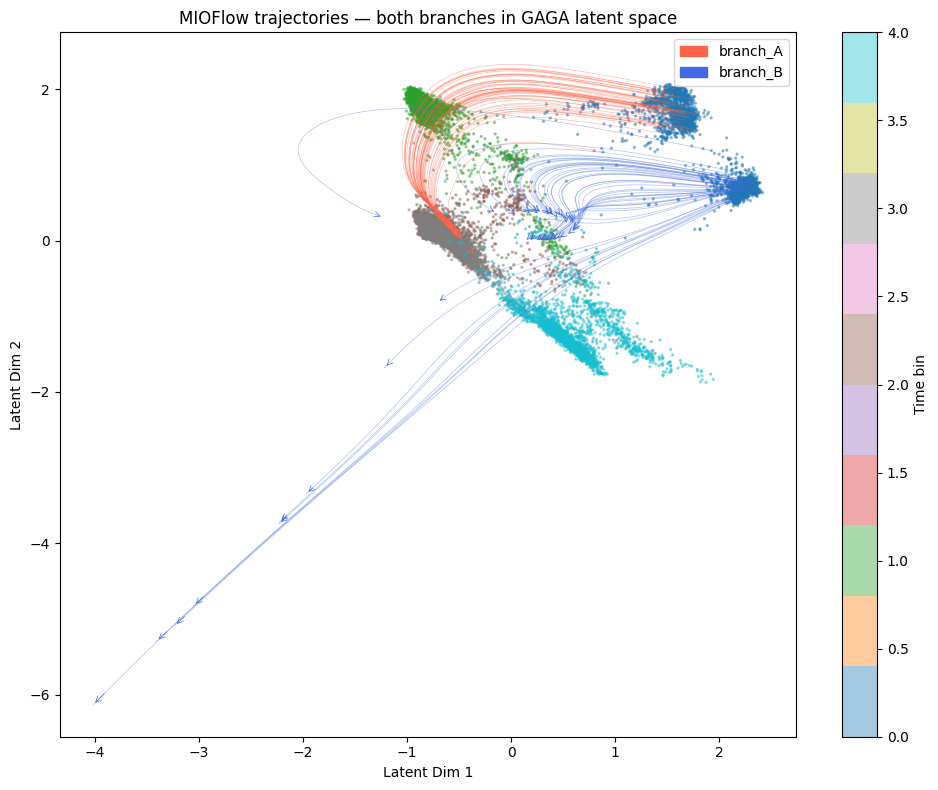

In [27]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 8))

# Background: all cells coloured by time
sc_plot = ax.scatter(
    adata.obsm['X_gaga'][:, 0], adata.obsm['X_gaga'][:, 1],
    c=adata.obs[time_column], cmap='tab10', s=2, alpha=0.4,
)
plt.colorbar(sc_plot, ax=ax, label='Time bin')

for branch, model in mioflow_models.items():
    color = branch_colors[branch]
    for traj in model.trajectories.transpose(1, 0, 2):
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.4, linewidth=0.5, color=color)
        ax.annotate(
            '', xy=(traj[-1, 0], traj[-1, 1]), xytext=(traj[-2, 0], traj[-2, 1]),
            arrowprops=dict(arrowstyle='->', color=color, lw=0.5, mutation_scale=10),
        )

ax.legend(handles=[Patch(color=c, label=b) for b, c in branch_colors.items()])
ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_title('MIOFlow trajectories — both branches in GAGA latent space')
plt.tight_layout()
plt.show()

## 8. Decode to Gene Space

`decode_to_gene_space()` maps trajectories through:

**GAGA latent → GAGA decoder → PCA space → gene space**

Returns shape **`(n_bins, n_trajectories, n_genes)`**.

In [28]:
trajectories_gene_space = {
    branch: model.decode_to_gene_space()
    for branch, model in mioflow_models.items()
}
# Combined along trajectory axis for shared analyses
trajectories_gene_space_all = np.concatenate(
    list(trajectories_gene_space.values()), axis=1
)
print('Per-branch shapes:', {b: t.shape for b, t in trajectories_gene_space.items()})
print('Combined shape (n_bins, n_traj_total, n_genes):', trajectories_gene_space_all.shape)

Per-branch shapes: {'branch_A': (100, 50, 19366), 'branch_B': (100, 50, 19366)}
Combined shape (n_bins, n_traj_total, n_genes): (100, 100, 19366)


## 9. Gene Trends — Top Variable Genes

We select top genes by variance across the decoded trajectories and plot mean expression (± std) per branch.

In [29]:
# Select top variable genes by variance across all decoded trajectories
n_top = 25
gene_var = trajectories_gene_space_all.reshape(-1, trajectories_gene_space_all.shape[-1]).var(axis=0)
top_gene_idx = np.argsort(gene_var)[::-1][:n_top]
example_genes = adata.var_names[top_gene_idx]
example_gene_mask = np.zeros(adata.n_vars, dtype=bool)
example_gene_mask[top_gene_idx] = True

print('Top variable genes:', list(example_genes))

Top variable genes: ['MALAT1', 'FTH1', 'MT-CO2', 'MT-CO1', 'H2AFZ', 'AREG', 'MT-CO3', 'FTL', 'HMGB1', 'PTMA', 'MT-ND4', 'H3.Y', 'MGP', 'MSMP', 'RPS2', 'FABP5', 'MT-ND2', 'RPLP1', 'S100A6', 'KRT19', 'TMSB4X', 'HMGN2', 'CDKN3', 'MT-CYB', 'IGFBP5']


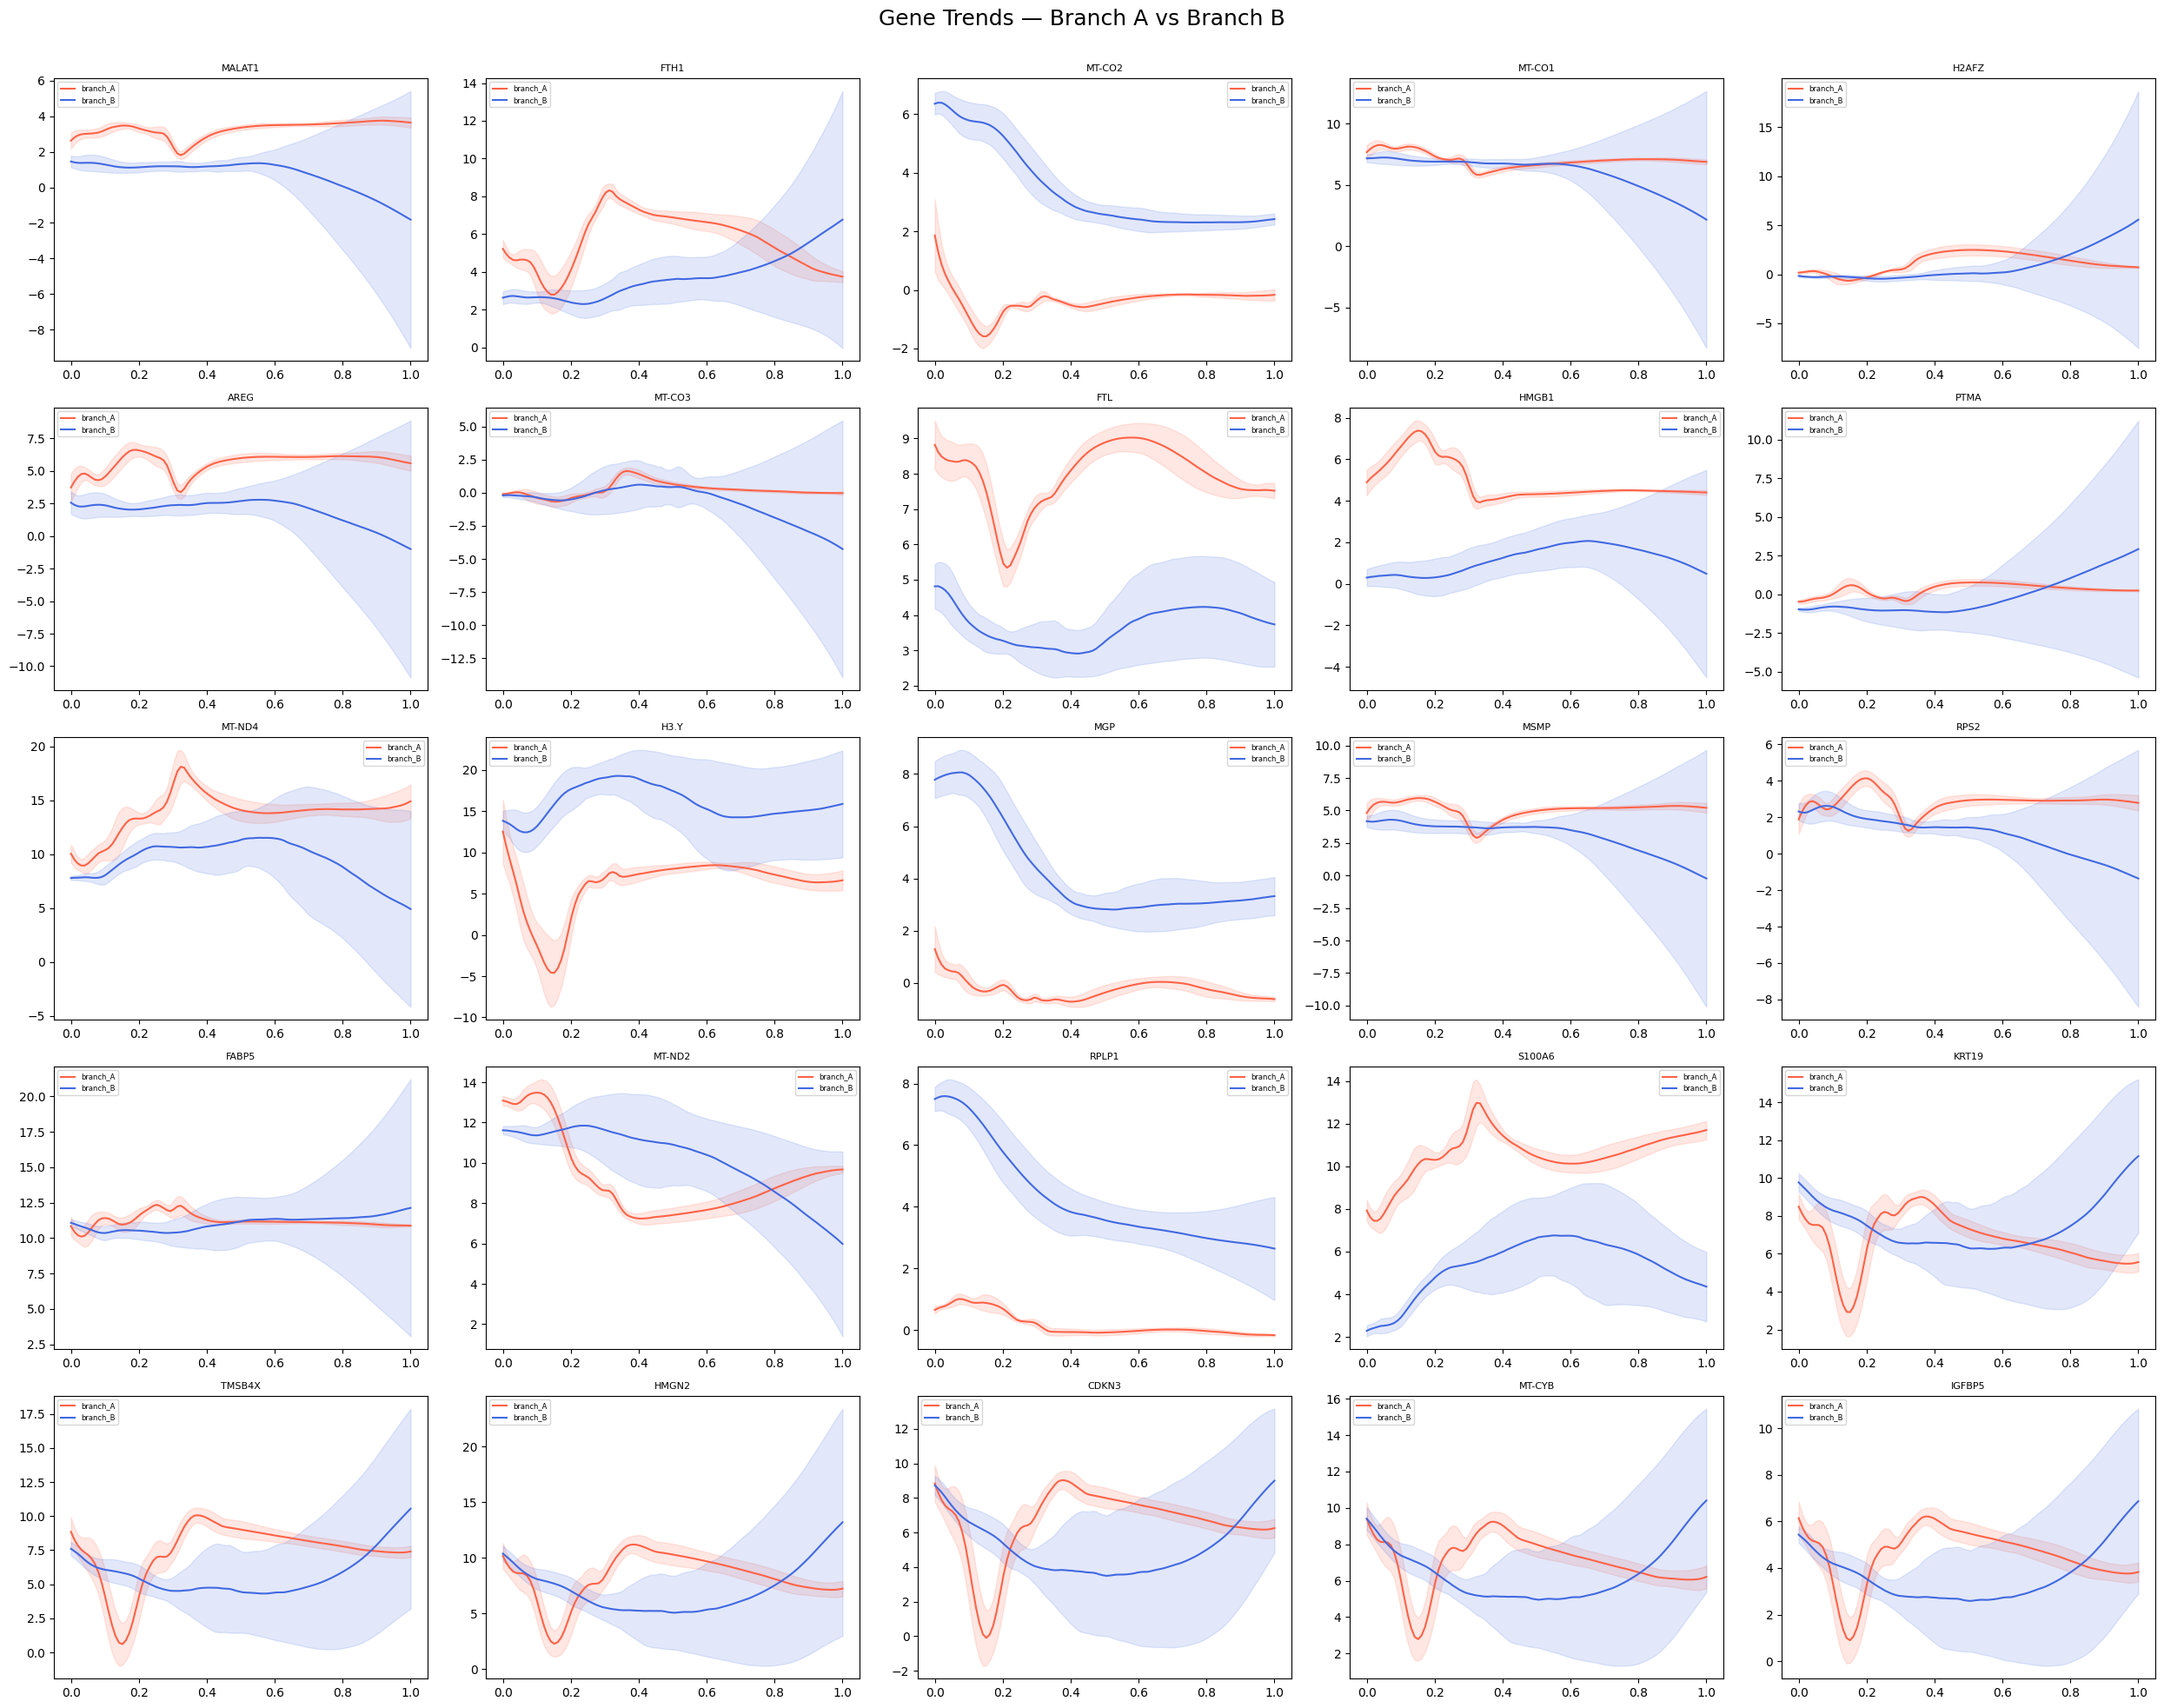

In [30]:
x_time = np.linspace(0, 1, list(mioflow_models.values())[0].trajectories.shape[0])

n_genes = len(example_genes)
n_cols  = int(np.ceil(np.sqrt(n_genes)))
n_rows  = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, gene in enumerate(example_genes):
    ax = axes[i]
    for branch, tgs in trajectories_gene_space.items():
        decoded = tgs[:, :, example_gene_mask][:, :, i]   # (n_bins, n_traj)
        mean = decoded.mean(axis=1)
        std  = decoded.std(axis=1)
        color = branch_colors[branch]
        ax.plot(x_time, mean, color=color, label=branch)
        ax.fill_between(x_time, mean - std, mean + std, alpha=0.15, color=color)
    ax.set_title(gene, fontsize=8)
    ax.legend(fontsize=6)

for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Gene Trends — Branch A vs Branch B', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()